<a href="https://colab.research.google.com/github/Linhlak/AI-practicals/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD FAOSTAT DATA
# ============================================================

# Corrected file path to use the uploaded .xls file
file_path = "/content/FAOSTAT_data_en_8-10-2026.xls"

df = pd.read_excel(file_path, engine="xlrd")

print("\nOriginal dataset shape:", df.shape)

# ============================================================
# 2. SELECT ONLY YEAR AND YIELD
# ============================================================

# Keep only records where Element = Yield
yield_data = df[df["Element"].str.strip().str.lower() == "yield"].copy()

# Select ONLY Year and Value
data = yield_data[["Year", "Value"]].copy()

# Rename Value to Yield
data.rename(columns={"Value": "Yield"}, inplace=True)

# Convert to numeric
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data["Yield"] = pd.to_numeric(data["Yield"], errors="coerce")

# Remove missing values
data.dropna(inplace=True)

# Sort by year
data.sort_values("Year", inplace=True)
data.reset_index(drop=True, inplace=True)

print("\nData using only Year and Yield:")
print(data.head(10))

print("\nNumber of observations:", len(data))
print("Year range:", data["Year"].min(), "-", data["Year"].max())

# ============================================================
# 3. LINEAR REGRESSION
# ============================================================

X = data[["Year"]]
y = data["Yield"]

# ------------------------------------------------------------
# Chronological 80% training / 20% testing
# ------------------------------------------------------------

split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

# Create Linear Regression model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predict test data
y_test_pred = linear_model.predict(X_test)

# ============================================================
# 4. REGRESSION METRICS
# ============================================================

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n========================================")
print("LINEAR REGRESSION RESULTS")
print("========================================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("\nMSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

# ============================================================
# 5. TRAIN FINAL MODEL USING ALL AVAILABLE DATA
# ============================================================

final_model = LinearRegression()
final_model.fit(X, y)

# ============================================================
# 6. PREDICT 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_years = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030]
})

future_predictions = final_model.predict(future_years)

prediction_table = pd.DataFrame({
    "Year": future_years["Year"],
    "Predicted_Yield": future_predictions
})

print("\n========================================")
print("PREDICTION FOR 2027-2030")
print("========================================")

print(prediction_table.to_string(index=False))

# ============================================================
# 7. CLASSIFICATION
# ============================================================
#
# Since Yield is a continuous value, it is not naturally a
# classification target.
#
# We create two classes:
#
# 0 = Low Yield
# 1 = High Yield
#
# The median yield is used as the threshold.
# ============================================================

median_yield = y.median()

data["Yield_Class"] = (data["Yield"] >= median_yield).astype(int)

print("\n========================================")
print("CLASSIFICATION")
print("========================================")

print("Median Yield:", median_yield)
print("\nClass definition:")
print("0 = Low Yield")
print("1 = High Yield")

# Features and target
X_class = data[["Year"]]
y_class = data["Yield_Class"]

# Stratified/random split is better for classification because
# both classes should appear in training and testing data.
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Logistic Regression classifier
classifier = LogisticRegression(max_iter=1000)

classifier.fit(Xc_train, yc_train)

# Predict classes
yc_pred = classifier.predict(Xc_test)

# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(yc_test, yc_pred)
precision = precision_score(yc_test, yc_pred, zero_division=0)
recall = recall_score(yc_test, yc_pred, zero_division=0)
f1 = f1_score(yc_test, yc_pred, zero_division=0)

cm = confusion_matrix(yc_test, yc_pred)

print("\n========================================")
print("CLASSIFICATION RESULTS")
print("========================================")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    yc_test,
    yc_pred,
    target_names=["Low Yield", "High Yield"],
    zero_division=0
))

# ============================================================
# 9. CLASSIFY 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_class = classifier.predict(future_years)

future_probability = classifier.predict_proba(future_years)[:, 1]

classification_predictions = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030],
    "Predicted_Yield": future_predictions,
    "Class": future_class,
    "High_Yield_Probability": future_probability
})

classification_predictions["Class"] = classification_predictions[
    "Class"
].map({
    0: "Low Yield",
    1: "High Yield"
})

print("\n========================================")
print("2027-2030 CLASSIFICATION")
print("========================================")

print(classification_predictions.to_string(index=False))

# ============================================================
# 10. SAVE RESULTS
# ============================================================

prediction_table.to_csv(
    "linear_regression_predictions_2027_2030.csv",
    index=False
)

classification_predictions.to_csv(
    "classification_predictions_2027_2030.csv",
    index=False
)

print("\n========================================")
print("FILES SAVED")
print("========================================")

print("linear_regression_predictions_2027_2030.csv")
print("classification_predictions_2027_2030.csv")


Original dataset shape: (9645, 15)

Data using only Year and Yield:
   Year    Yield
0  1961     73.0
1  1961    100.0
2  1961   1092.1
3  1961    896.2
4  1961    728.9
5  1961   5263.2
6  1961   6000.0
7  1961  60288.3
8  1961    650.7
9  1961   1978.9

Number of observations: 1831
Year range: 1961 - 2024

Training observations: 1464
Testing observations: 367

LINEAR REGRESSION RESULTS
Slope: -7.70355709840349
Intercept: 20291.345704044033

MSE  : 51413284.124567285
RMSE : 7170.305720439491
MAE  : 4616.590990172201
R2   : -0.030054518897715043

PREDICTION FOR 2027-2030
 Year  Predicted_Yield
 2027      5496.055555
 2028      5506.556919
 2029      5517.058282
 2030      5527.559646

CLASSIFICATION
Median Yield: 2069.9

Class definition:
0 = Low Yield
1 = High Yield

CLASSIFICATION RESULTS
Accuracy  : 0.5994550408719346
Precision : 0.5939086294416244
Recall    : 0.6358695652173914
F1 Score  : 0.6141732283464567

Confusion Matrix:
[[103  80]
 [ 67 117]]

Classification Report:
       

In [ ]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD FAOSTAT DATA
# ============================================================

# Corrected file path to use the uploaded .xls file
file_path = "/content/FAOSTAT_data_en_8-10-2026.xls"

df = pd.read_excel(file_path, engine="xlrd")

print("\nOriginal dataset shape:", df.shape)

# ============================================================
# 2. SELECT ONLY YEAR AND YIELD
# ============================================================

# Keep only records where Element = Yield
yield_data = df[df["Element"].str.strip().str.lower() == "yield"].copy()

# Select ONLY Year and Value
data = yield_data[["Year", "Value"]].copy()

# Rename Value to Yield
data.rename(columns={"Value": "Yield"}, inplace=True)

# Convert to numeric
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data["Yield"] = pd.to_numeric(data["Yield"], errors="coerce")

# Remove missing values
data.dropna(inplace=True)

# Sort by year
data.sort_values("Year", inplace=True)
data.reset_index(drop=True, inplace=True)

print("\nData using only Year and Yield:")
print(data.head(10))

print("\nNumber of observations:", len(data))
print("Year range:", data["Year"].min(), "-", data["Year"].max())

# ============================================================
# 3. LINEAR REGRESSION
# ============================================================

X = data[["Year"]]
y = data["Yield"]

# ------------------------------------------------------------
# Chronological 80% training / 20% testing
# ------------------------------------------------------------

split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

# Create Linear Regression model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predict test data
y_test_pred = linear_model.predict(X_test)

# ============================================================
# 4. REGRESSION METRICS
# ============================================================

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n========================================")
print("LINEAR REGRESSION RESULTS")
print("========================================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("\nMSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

# ============================================================
# 5. TRAIN FINAL MODEL USING ALL AVAILABLE DATA
# ============================================================

final_model = LinearRegression()
final_model.fit(X, y)

# ============================================================
# 6. PREDICT 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_years = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030]
})

future_predictions = final_model.predict(future_years)

prediction_table = pd.DataFrame({
    "Year": future_years["Year"],
    "Predicted_Yield": future_predictions
})

print("\n========================================")
print("PREDICTION FOR 2027-2030")
print("========================================")

print(prediction_table.to_string(index=False))

# ============================================================
# 7. CLASSIFICATION
# ============================================================
#
# Since Yield is a continuous value, it is not naturally a
# classification target.
#
# We create two classes:
#
# 0 = Low Yield
# 1 = High Yield
#
# The median yield is used as the threshold.
# ============================================================

median_yield = y.median()

data["Yield_Class"] = (data["Yield"] >= median_yield).astype(int)

print("\n========================================")
print("CLASSIFICATION")
print("========================================")

print("Median Yield:", median_yield)
print("\nClass definition:")
print("0 = Low Yield")
print("1 = High Yield")

# Features and target
X_class = data[["Year"]]
y_class = data["Yield_Class"]

# Stratified/random split is better for classification because
# both classes should appear in training and testing data.
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Logistic Regression classifier
classifier = LogisticRegression(max_iter=1000)

classifier.fit(Xc_train, yc_train)

# Predict classes
yc_pred = classifier.predict(Xc_test)

# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(yc_test, yc_pred)
precision = precision_score(yc_test, yc_pred, zero_division=0)
recall = recall_score(yc_test, yc_pred, zero_division=0)
f1 = f1_score(yc_test, yc_pred, zero_division=0)

cm = confusion_matrix(yc_test, yc_pred)

print("\n========================================")
print("CLASSIFICATION RESULTS")
print("========================================")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    yc_test,
    yc_pred,
    target_names=["Low Yield", "High Yield"],
    zero_division=0
))

# ============================================================
# 9. CLASSIFY 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_class = classifier.predict(future_years)

future_probability = classifier.predict_proba(future_years)[:, 1]

classification_predictions = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030],
    "Predicted_Yield": future_predictions,
    "Class": future_class,
    "High_Yield_Probability": future_probability
})

classification_predictions["Class"] = classification_predictions[
    "Class"
].map({
    0: "Low Yield",
    1: "High Yield"
})

print("\n========================================")
print("2027-2030 CLASSIFICATION")
print("========================================")

print(classification_predictions.to_string(index=False))

# ============================================================
# 10. SAVE RESULTS
# ============================================================

prediction_table.to_csv(
    "linear_regression_predictions_2027_2030.csv",
    index=False
)

classification_predictions.to_csv(
    "classification_predictions_2027_2030.csv",
    index=False
)

print("\n========================================")
print("FILES SAVED")
print("========================================")

print("linear_regression_predictions_2027_2030.csv")
print("classification_predictions_2027_2030.csv")


Original dataset shape: (9645, 15)

Data using only Year and Yield:
   Year    Yield
0  1961     73.0
1  1961    100.0
2  1961   1092.1
3  1961    896.2
4  1961    728.9
5  1961   5263.2
6  1961   6000.0
7  1961  60288.3
8  1961    650.7
9  1961   1978.9

Number of observations: 1831
Year range: 1961 - 2024

Training observations: 1464
Testing observations: 367

LINEAR REGRESSION RESULTS
Slope: -7.70355709840349
Intercept: 20291.345704044033

MSE  : 51413284.124567285
RMSE : 7170.305720439491
MAE  : 4616.590990172201
R2   : -0.030054518897715043

PREDICTION FOR 2027-2030
 Year  Predicted_Yield
 2027      5496.055555
 2028      5506.556919
 2029      5517.058282
 2030      5527.559646

CLASSIFICATION
Median Yield: 2069.9

Class definition:
0 = Low Yield
1 = High Yield

CLASSIFICATION RESULTS
Accuracy  : 0.5994550408719346
Precision : 0.5939086294416244
Recall    : 0.6358695652173914
F1 Score  : 0.6141732283464567

Confusion Matrix:
[[103  80]
 [ 67 117]]

Classification Report:
       

In [9]:
from google.colab import files

print('Please upload the file: FAOSTAT_data_en_8-11-2026(1).xlsx')
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Please upload the file: FAOSTAT_data_en_8-11-2026(1).xlsx


Saving FAOSTAT_data_en_8-10-2026.xls to FAOSTAT_data_en_8-10-2026.xls
User uploaded file "FAOSTAT_data_en_8-10-2026.xls" with length 4169728 bytes


In [13]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD FAOSTAT DATA
# ============================================================

# Corrected file path to use the uploaded .xls file
file_path = "/content/FAOSTAT_data_en_8-10-2026.xls"

df = pd.read_excel(file_path, engine="xlrd")

print("\nOriginal dataset shape:", df.shape)

# ============================================================
# 2. SELECT ONLY YEAR AND YIELD
# ============================================================

# Keep only records where Element = Yield
yield_data = df[df["Element"].str.strip().str.lower() == "yield"].copy()

# Select ONLY Year and Value
data = yield_data[["Year", "Value"]].copy()

# Rename Value to Yield
data.rename(columns={"Value": "Yield"}, inplace=True)

# Convert to numeric
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")
data["Yield"] = pd.to_numeric(data["Yield"], errors="coerce")

# Remove missing values
data.dropna(inplace=True)

# Sort by year
data.sort_values("Year", inplace=True)
data.reset_index(drop=True, inplace=True)

print("\nData using only Year and Yield:")
print(data.head(10))

print("\nNumber of observations:", len(data))
print("Year range:", data["Year"].min(), "-", data["Year"].max())

# ============================================================
# 3. LINEAR REGRESSION
# ============================================================

X = data[["Year"]]
y = data["Yield"]

# ------------------------------------------------------------
# Chronological 80% training / 20% testing
# ------------------------------------------------------------

split_index = int(len(data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))

# Create Linear Regression model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predict test data
y_test_pred = linear_model.predict(X_test)

# ============================================================
# 4. REGRESSION METRICS
# ============================================================

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n========================================")
print("LINEAR REGRESSION RESULTS")
print("========================================")

print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)

print("\nMSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)

# ============================================================
# 5. TRAIN FINAL MODEL USING ALL AVAILABLE DATA
# ============================================================

final_model = LinearRegression()
final_model.fit(X, y)

# ============================================================
# 6. PREDICT 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_years = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030]
})

future_predictions = final_model.predict(future_years)

prediction_table = pd.DataFrame({
    "Year": future_years["Year"],
    "Predicted_Yield": future_predictions
})

print("\n========================================")
print("PREDICTION FOR 2027-2030")
print("========================================")

print(prediction_table.to_string(index=False))

# ============================================================
# 7. CLASSIFICATION
# ============================================================
#
# Since Yield is a continuous value, it is not naturally a
# classification target.
#
# We create two classes:
#
# 0 = Low Yield
# 1 = High Yield
#
# The median yield is used as the threshold.
# ============================================================

median_yield = y.median()

data["Yield_Class"] = (data["Yield"] >= median_yield).astype(int)

print("\n========================================")
print("CLASSIFICATION")
print("========================================")

print("Median Yield:", median_yield)
print("\nClass definition:")
print("0 = Low Yield")
print("1 = High Yield")

# Features and target
X_class = data[["Year"]]
y_class = data["Yield_Class"]

# Stratified/random split is better for classification because
# both classes should appear in training and testing data.
from sklearn.model_selection import train_test_split

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Logistic Regression classifier
classifier = LogisticRegression(max_iter=1000)

classifier.fit(Xc_train, yc_train)

# Predict classes
yc_pred = classifier.predict(Xc_test)

# ============================================================
# 8. CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(yc_test, yc_pred)
precision = precision_score(yc_test, yc_pred, zero_division=0)
recall = recall_score(yc_test, yc_pred, zero_division=0)
f1 = f1_score(yc_test, yc_pred, zero_division=0)

cm = confusion_matrix(yc_test, yc_pred)

print("\n========================================")
print("CLASSIFICATION RESULTS")
print("========================================")

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    yc_test,
    yc_pred,
    target_names=["Low Yield", "High Yield"],
    zero_division=0
))

# ============================================================
# 9. CLASSIFY 2027-2030 (assuming 20727-30 was a typo)
# ============================================================

future_class = classifier.predict(future_years)

future_probability = classifier.predict_proba(future_years)[:, 1]

classification_predictions = pd.DataFrame({
    "Year": [2027, 2028, 2029, 2030],
    "Predicted_Yield": future_predictions,
    "Class": future_class,
    "High_Yield_Probability": future_probability
})

classification_predictions["Class"] = classification_predictions[
    "Class"
].map({
    0: "Low Yield",
    1: "High Yield"
})

print("\n========================================")
print("2027-2030 CLASSIFICATION")
print("========================================")

print(classification_predictions.to_string(index=False))

# ============================================================
# 10. SAVE RESULTS
# ============================================================

prediction_table.to_csv(
    "linear_regression_predictions_2027_2030.csv",
    index=False
)

classification_predictions.to_csv(
    "classification_predictions_2027_2030.csv",
    index=False
)

print("\n========================================")
print("FILES SAVED")
print("========================================")

print("linear_regression_predictions_2027_2030.csv")
print("classification_predictions_2027_2030.csv")


Original dataset shape: (9645, 15)

Data using only Year and Yield:
   Year    Yield
0  1961     73.0
1  1961    100.0
2  1961   1092.1
3  1961    896.2
4  1961    728.9
5  1961   5263.2
6  1961   6000.0
7  1961  60288.3
8  1961    650.7
9  1961   1978.9

Number of observations: 1831
Year range: 1961 - 2024

Training observations: 1464
Testing observations: 367

LINEAR REGRESSION RESULTS
Slope: -7.70355709840349
Intercept: 20291.345704044033

MSE  : 51413284.124567285
RMSE : 7170.305720439491
MAE  : 4616.590990172201
R2   : -0.030054518897715043

PREDICTION FOR 2027-2030
 Year  Predicted_Yield
 2027      5496.055555
 2028      5506.556919
 2029      5517.058282
 2030      5527.559646

CLASSIFICATION
Median Yield: 2069.9

Class definition:
0 = Low Yield
1 = High Yield

CLASSIFICATION RESULTS
Accuracy  : 0.5994550408719346
Precision : 0.5939086294416244
Recall    : 0.6358695652173914
F1 Score  : 0.6141732283464567

Confusion Matrix:
[[103  80]
 [ 67 117]]

Classification Report:
       

## Polynomial Regression

Given the low R2 score and the visual representation of the linear regression, a polynomial regression model might provide a better fit for the data. This involves transforming the 'Year' feature into polynomial terms before applying a linear regression model.

In [15]:
from sklearn.preprocessing import PolynomialFeatures

# Choose the degree of the polynomial. A common starting point is degree 2 or 3.
degree = 2
polynomial_features = PolynomialFeatures(degree=degree)
X_poly = polynomial_features.fit_transform(X)

# Split the polynomial features into training and testing sets
X_train_poly = polynomial_features.transform(X_train)
X_test_poly = polynomial_features.transform(X_test)

# Train a Linear Regression model on the polynomial features
polynomial_model = LinearRegression()
polynomial_model.fit(X_train_poly, y_train)

# Predict test data using the polynomial model
y_test_pred_poly = polynomial_model.predict(X_test_poly)

# Calculate and display metrics for polynomial regression
mse_poly = mean_squared_error(y_test, y_test_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_test_pred_poly)
r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"\n========================================")
print(f"POLYNOMIAL REGRESSION (DEGREE {degree}) RESULTS")
print(f"========================================")
print(f"MSE  : {mse_poly}")
print(f"RMSE : {rmse_poly}")
print(f"MAE  : {mae_poly}")
print(f"R2   : {r2_poly}")


POLYNOMIAL REGRESSION (DEGREE 2) RESULTS
MSE  : 51067541.22405648
RMSE : 7146.155695481067
MAE  : 5171.421333186313
R2   : -0.023127631360535084


### Visualize Polynomial Regression Results

Now, let's visualize the polynomial regression line against the actual data to see if the fit has improved.

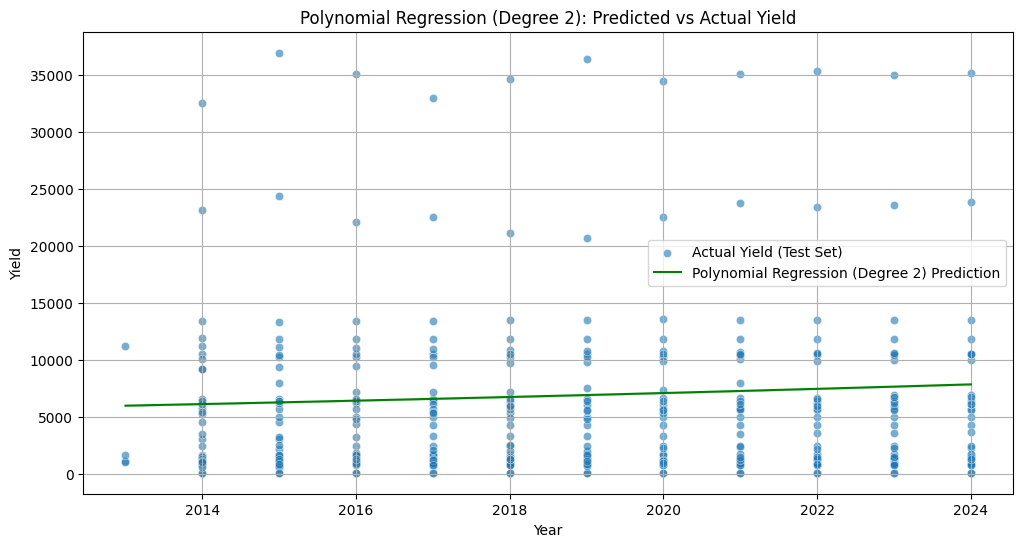


POLYNOMIAL REGRESSION (DEGREE 2) PREDICTION FOR 2027-2030
 Year  Predicted_Yield
 2027      8476.133476
 2028      8697.807833
 2029      8925.237755
 2030      9158.423240

Polynomial regression predictions saved to: polynomial_regression_predictions_degree_2_2027_2030.csv


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data for a smoother line plot
sort_idx = X_test['Year'].argsort()
X_test_sorted = X_test['Year'].iloc[sort_idx]
y_test_sorted = y_test.iloc[sort_idx]
y_test_pred_poly_sorted = y_test_pred_poly[sort_idx]

plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test_sorted, y=y_test_sorted, label='Actual Yield (Test Set)', alpha=0.6)
sns.lineplot(x=X_test_sorted, y=y_test_pred_poly_sorted, color='green', label=f'Polynomial Regression (Degree {degree}) Prediction')
plt.title(f'Polynomial Regression (Degree {degree}): Predicted vs Actual Yield')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)
plt.show()

# Predict future years with the polynomial model
future_years_poly = polynomial_features.transform(future_years)
future_predictions_poly = polynomial_model.predict(future_years_poly)

polynomial_prediction_table = pd.DataFrame({
    "Year": future_years["Year"],
    "Predicted_Yield": future_predictions_poly
})

print("\n========================================")
print(f"POLYNOMIAL REGRESSION (DEGREE {degree}) PREDICTION FOR 2027-2030")
print("========================================")
print(polynomial_prediction_table.to_string(index=False))

# Save the polynomial regression predictions
polynomial_prediction_table.to_csv(
    f"polynomial_regression_predictions_degree_{degree}_2027_2030.csv",
    index=False
)

print(f"\nPolynomial regression predictions saved to: polynomial_regression_predictions_degree_{degree}_2027_2030.csv")

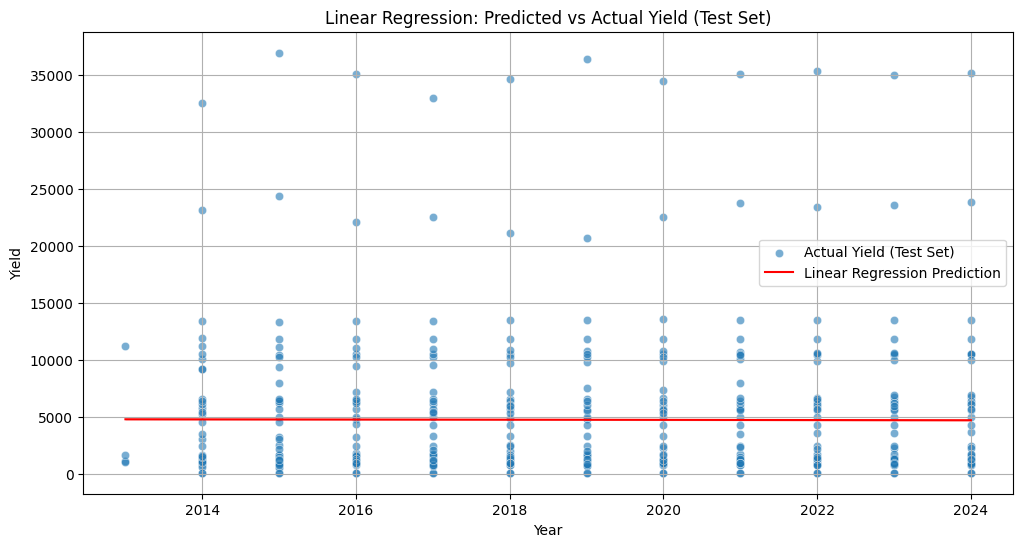

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test['Year'], y=y_test, label='Actual Yield (Test Set)', alpha=0.6)
sns.lineplot(x=X_test['Year'], y=y_test_pred, color='red', label='Linear Regression Prediction')
plt.title('Linear Regression: Predicted vs Actual Yield (Test Set)')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)
plt.show()

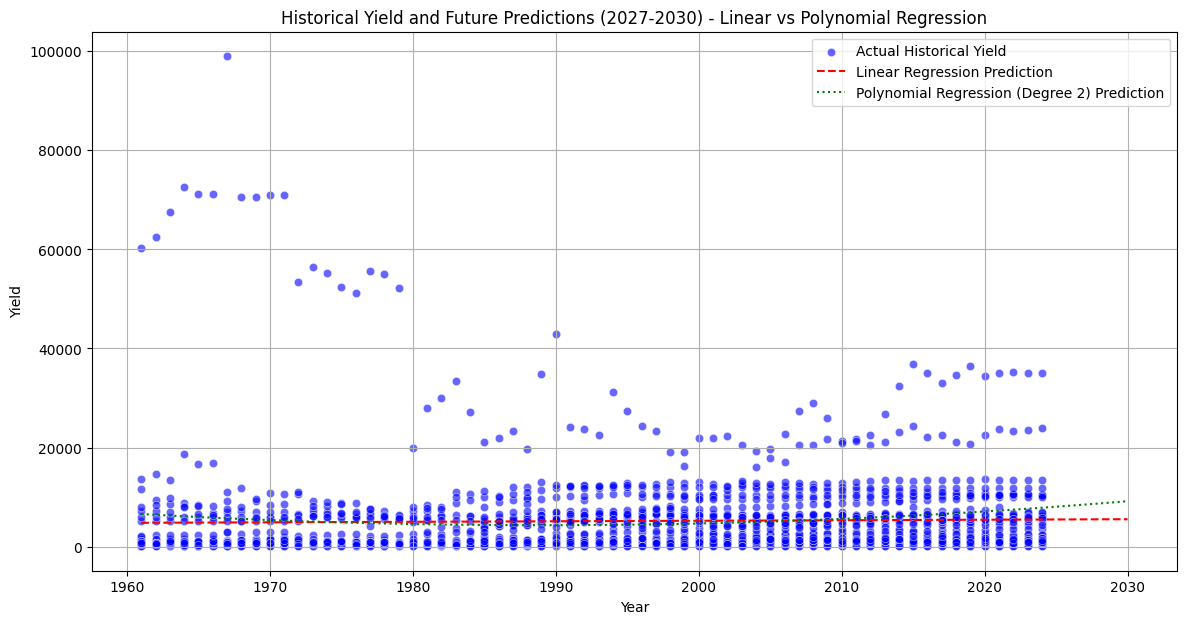

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create an extended range of years for plotting future predictions smoothly
extended_years = pd.DataFrame({'Year': np.arange(data['Year'].min(), 2031)}) # Extend to 2030

# Predict over the extended range using the final linear model
linear_predictions_extended = final_model.predict(extended_years)

# Predict over the extended range using the final polynomial model
extended_years_poly = polynomial_features.transform(extended_years)
polynomial_predictions_extended = polynomial_model.predict(extended_years_poly)

plt.figure(figsize=(14, 7))
sns.scatterplot(x=data['Year'], y=data['Yield'], label='Actual Historical Yield', alpha=0.6, color='blue')
sns.lineplot(x=extended_years['Year'], y=linear_predictions_extended, color='red', label='Linear Regression Prediction', linestyle='--')
sns.lineplot(x=extended_years['Year'], y=polynomial_predictions_extended, color='green', label=f'Polynomial Regression (Degree {degree}) Prediction', linestyle=':')

plt.title('Historical Yield and Future Predictions (2027-2030) - Linear vs Polynomial Regression')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)
plt.show()

### Classification Predictions for 2027-2030

Below are the classification predictions for the years 2027-2030, showing the predicted yield class (Low/High Yield) and the probability of being a High Yield year, based on the Logistic Regression model.

In [19]:
display(classification_predictions)

,Year,Predicted_Yield,Class,High_Yield_Probability
0,2027,5496.055555,High Yield,0.642032
1,2028,5506.556919,High Yield,0.646261
2,2029,5517.058282,High Yield,0.650466
3,2030,5527.559646,High Yield,0.654649


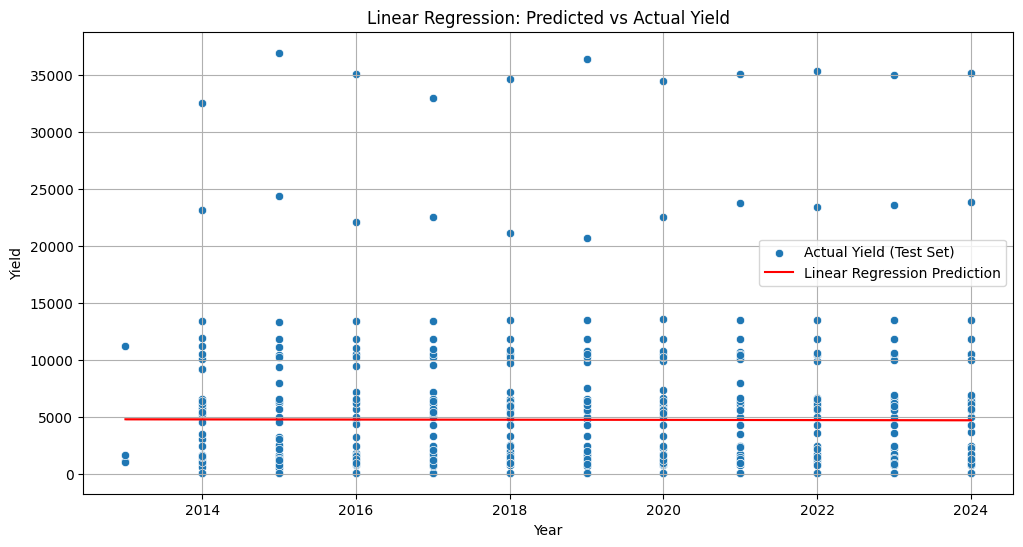

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x=X_test['Year'], y=y_test, label='Actual Yield (Test Set)')
sns.lineplot(x=X_test['Year'], y=y_test_pred, color='red', label='Linear Regression Prediction')
plt.title('Linear Regression: Predicted vs Actual Yield')
plt.xlabel('Year')
plt.ylabel('Yield')
plt.legend()
plt.grid(True)
plt.show()

After uploading the file, you can re-run the previous cell (cell `IzAbn2jFQDti`) to continue with the analysis, as the `FileNotFoundError` should now be resolved.

# Welcome to Colab!

## Google Colab is available in VS Code!
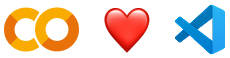

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  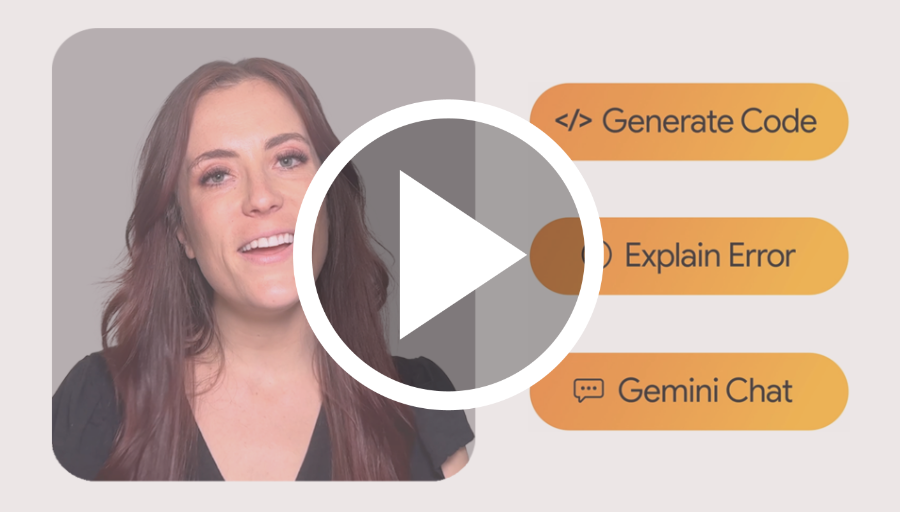
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

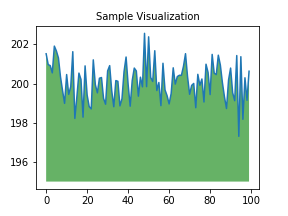

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
